# Important CNN Designs

## Start with the engineering question behind an architecture name

Suppose a basic CNN already works, but the next experiment needs more depth, several spatial scales, or lower computation. Adding layers indiscriminately may increase cost without solving the actual constraint.

Important CNN families are useful because they introduce structural ideas: regular stacks of small filters, parallel branches, residual addition, explicit feature reuse, and restricted spatial/channel mixing. Understanding those ideas lets you inspect a design instead of treating its name as a guarantee of accuracy.

We will compare the structures, work residual arithmetic, derive bottleneck and depthwise parameter counts, and distinguish a cheaper operation count from measured speed. The [code companion](35_Important_CNN_Designs.ipynb) checks a small residual block's shape and counts parameters in standard and depthwise-separable convolutions.

It does not train or benchmark these designs. This lesson therefore supplies transparent calculations and design questions rather than a performance ranking. [CNN Architecture and Training](34_CNN_Architecture_and_Training_Notes.ipynb) explains how to evaluate an architecture once its data and prediction task are defined.


## Recognize the structural patterns first

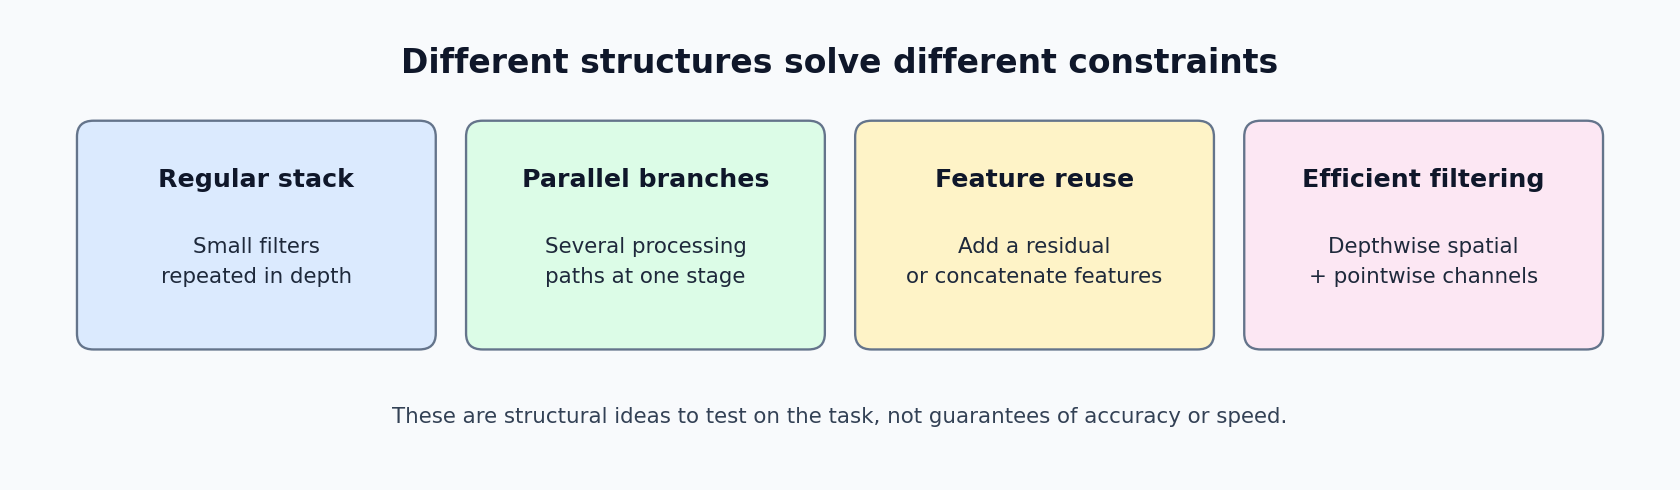

| Family | Core structure | Useful question |
| --- | --- | --- |
| LeNet-style | Compact convolution and pooling stages | What can a small image classifier accomplish? |
| VGG-style | Repeated small spatial filters | How far can a regular deeper stack go? |
| Inception-style | Parallel branches joined by channels | Which local scales should be processed together? |
| ResNet-style | Learned residual branch plus shortcut | Can deeper updates preserve a direct path? |
| DenseNet-style | Concatenate earlier feature maps | Can explicit feature reuse help? |
| MobileNet-style | Depthwise spatial filtering and pointwise mixing | Can a restricted factorization reduce work? |

These labels describe representative ideas, not every variant or implementation detail. Exact channels, activations, normalization, and downsampling must be read from the actual model configuration.

Different designs can also combine several patterns. A lightweight block might use both a residual shortcut and depthwise filtering. Recognizing the components is more useful than assuming architecture families are mutually exclusive.


## Use a compact convolutional stack as a baseline

A LeNet-style teaching model alternates local convolution, activation, and spatial reduction before classification. It makes the basic path from image measurements to class evidence easy to trace.

For a small task, such a model can establish whether local filters help at all. Compare it with a suitable simpler baseline rather than assuming a large architecture is necessary because the input is an image.

| Stage choice | What to inspect |
| --- | --- |
| Input size and channels | Match the numerical data contract |
| Local filter widths | Match the spatial patterns of interest |
| Pooling or strides | Avoid discarding required detail too early |
| Flattened or pooled head | Match position sensitivity and parameter budget |

Compactness is not automatically sufficient. A task that requires precise locations or a wide context may need a different readout or deeper features. The baseline's value is that it makes a valid initial experiment and exposes which limitation the next architectural change is meant to address.

The line classifier in lesson 34 is one such compact teaching model, not an implementation of a named historical network in full.


## Build depth with repeated small filters

VGG-style networks emphasize regular stacks of small convolutional filters; see the [VGG paper](https://arxiv.org/abs/1409.1556). For a simplified comparison, use constant channel width $C$ and ignore biases and normalization.

Two stride-one three-by-three convolutions have nominal receptive-field extent five. Their weights total $2(3)(3)C^2=18C^2$. One five-by-five convolution at the same channel width has $25C^2$ weights.

| Construction | Nominal receptive field | Weights, stated assumptions |
| --- | --- | --- |
| One $5\times5$ convolution | 5 | $25C^2$ |
| Two $3\times3$ convolutions | 5 | $18C^2$ |

With $C=16$, the counts are 6400 and 4608. The stack has additional depth and can place a nonlinearity between its layers, so it is not generally equivalent to one larger linear kernel.

These counts do not describe a complete VGG model, whose stage widths and classifier also matter. Repeating a simple building block improves interpretability of the configuration, but extra layers still increase activation storage and optimization demands.


## Process several scales with parallel branches

Inception-style modules join outputs from parallel paths, often combining different spatial operations and one-by-one channel reductions. The [original Inception paper](https://arxiv.org/abs/1409.4842) motivates this multi-branch design.

For a teaching module, suppose four branches each output 16 channels at spatial shape $12\times12$. Concatenating them produces 64 channels at that same spatial shape. Concatenation requires compatible spatial dimensions; it does not average the branches.

A one-by-one reduction can reduce the cost of a later wider filter. For input width 32 and a three-by-three output width 16:

| Path, ignoring biases | Weight count |
| --- | --- |
| Direct $32\to16$ three-by-three | $32(16)(9)=4608$ |
| $32\to8$ one-by-one, then $8\to16$ three-by-three | $32(8)+8(16)(9)=1408$ |

The reduced path uses fewer weights but restricts intermediate channel capacity. It can be useful, yet the tradeoff must be tested with the task loss. Padding and stride choices must keep branch outputs spatially compatible before joining them.

Parallel branches increase design flexibility and implementation complexity. A visually elaborate diagram is not evidence that the module improves a particular dataset.


## Read a residual block as learning a correction

ResNet-style blocks add a learned branch to a shortcut, making residual updates explicit; see the [ResNet paper](https://arxiv.org/abs/1512.03385).

The basic addition is:

$$y=x+F(x).$$

For $x=[1,2]$ and selected branch output $F(x)=[0.2,-0.5]$, the sum is $[1.2,1.5]$. The learned branch can refine the input without having to recreate every unchanged coordinate.

| Quantity | Example |
| --- | --- |
| Input | $[1,2]$ |
| Learned change | $[0.2,-0.5]$ |
| Residual sum | $[1.2,1.5]$ |
| ReLU after sum | $[1.2,1.5]$ |

The companion includes a final ReLU, computing $\operatorname{ReLU}(x+F(x))$. For input $[-1,2]$ with the same selected change, the output would be $[0,1.5]$, not $[-0.8,1.5]$.

A zero residual branch preserves the input through the addition, but a subsequent activation can still change negative coordinates. State the entire block rather than treating all residual variants as exactly the bare equation.


## See the shortcut and learned branch as two paths

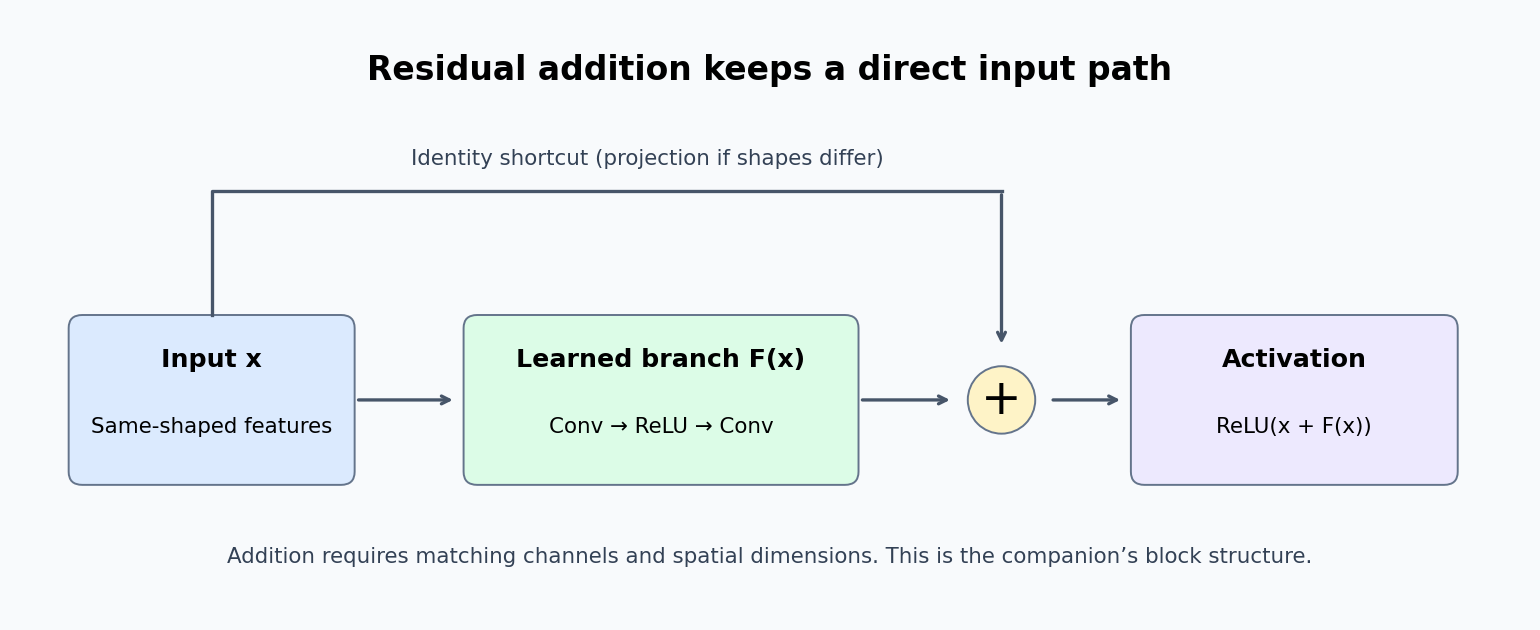

The companion's branch is a three-by-three convolution, ReLU, and another three-by-three convolution. Both convolutions preserve 16 channels and the $12\times12$ spatial grid through padding one.

| Object | Shape |
| --- | --- |
| Input | $(2,16,12,12)$ |
| First branch convolution | $(2,16,12,12)$ |
| Branch output | $(2,16,12,12)$ |
| Shortcut | $(2,16,12,12)$ |
| Added and activated result | $(2,16,12,12)$ |

Each bias-enabled convolution has $16(16(9)+1)=2320$ parameters, so the branch totals 4640. The identity shortcut and ReLUs contribute no parameters here.

Real residual architectures often include normalization and additional stage-transition choices. The companion omits those features intentionally. Its valid check is that this stated block preserves the specified shape, not that it reproduces a complete ResNet configuration or trained result.


## Match shortcut shapes and understand the gradient route

Addition requires matching channel and spatial dimensions. If a block changes from 16 channels at $12\times12$ to 32 channels at $6\times6$, an unchanged shortcut cannot be added directly. A one-by-one projection with stride two is one possible matching route.

Such a projection has $16(32)=512$ weights plus 32 biases if enabled. The projected shortcut is learned, so it is no longer a parameter-free identity.

For the bare residual equation, the input Jacobian is:

$$\frac{\partial y}{\partial x}=I+J_F(x).$$

This exposes a direct identity contribution. In a scalar example with $F(x)=0.2x$, derivative is 1.2. For $x=1$ and loss $L=\tfrac12y^2$, $y=1.2$, loss is 0.72, and the input derivative is $1.2(1.2)=1.44$.

This direct route can help optimization, but it is not a guarantee against vanishing or unstable gradients. Activations after addition, projections, and learned branch derivatives affect the full path. A final ReLU blocks gradients where its pre-activation is negative.


## Calculate a bottleneck instead of assuming every layer must be wide

A bottleneck block can reduce channels with a one-by-one convolution, perform spatial filtering at the reduced width, then expand channels with another one-by-one convolution.

For a selected $64\to16\to16\to64$ branch, ignoring biases and normalization:

| Layer | Weight count |
| --- | --- |
| $64\to16$, $1\times1$ | 1024 |
| $16\to16$, $3\times3$ | 2304 |
| $16\to64$, $1\times1$ | 1024 |
| Total | 4352 |

Two full-width $64\to64$ three-by-three convolutions use $2(64)(64)(9)=73728$ weights. The bottleneck spends much less spatial-filtering work at width sixteen.

It is a different parameterization and feature capacity, not the same function made automatically cheaper. Biases, normalization, nonlinearities, stride, and shortcut matching add details to a full implementation.

Because the branch begins and ends at width 64 with unchanged spatial dimensions in this teaching construction, an identity shortcut is shape-compatible. A stage transition would need a separate matching policy.


## Reuse features by concatenation rather than addition

DenseNet-style connectivity supplies earlier feature maps to later layers through concatenation; see the [DenseNet paper](https://arxiv.org/abs/1608.06993). This makes feature reuse explicit and changes how channel counts grow.

Suppose a teaching dense block starts with 16 channels and each layer adds eight new channels:

| Layer | Input channels | Newly produced channels | Available channels afterward |
| --- | --- | --- | --- |
| 1 | 16 | 8 | 24 |
| 2 | 24 | 8 | 32 |
| 3 | 32 | 8 | 40 |

In a simplified three-by-three-only construction, these layers have $8(16+24+32)(9)=5184$ weights, excluding biases and any bottleneck or normalization. This is not an exact count for a full named DenseNet model.

| Connection | Result for compatible 16-channel tensors |
| --- | --- |
| Add | 16 channels containing combined values |
| Concatenate | 32 channels retaining both sets of features |

Concatenation preserves feature sets explicitly, but more stored maps and growing channel widths can increase activation memory and later processing. Addition and concatenation solve different representation problems and should not be substituted without changing the following layer's interface.


## Separate per-channel spatial filters from channel mixing

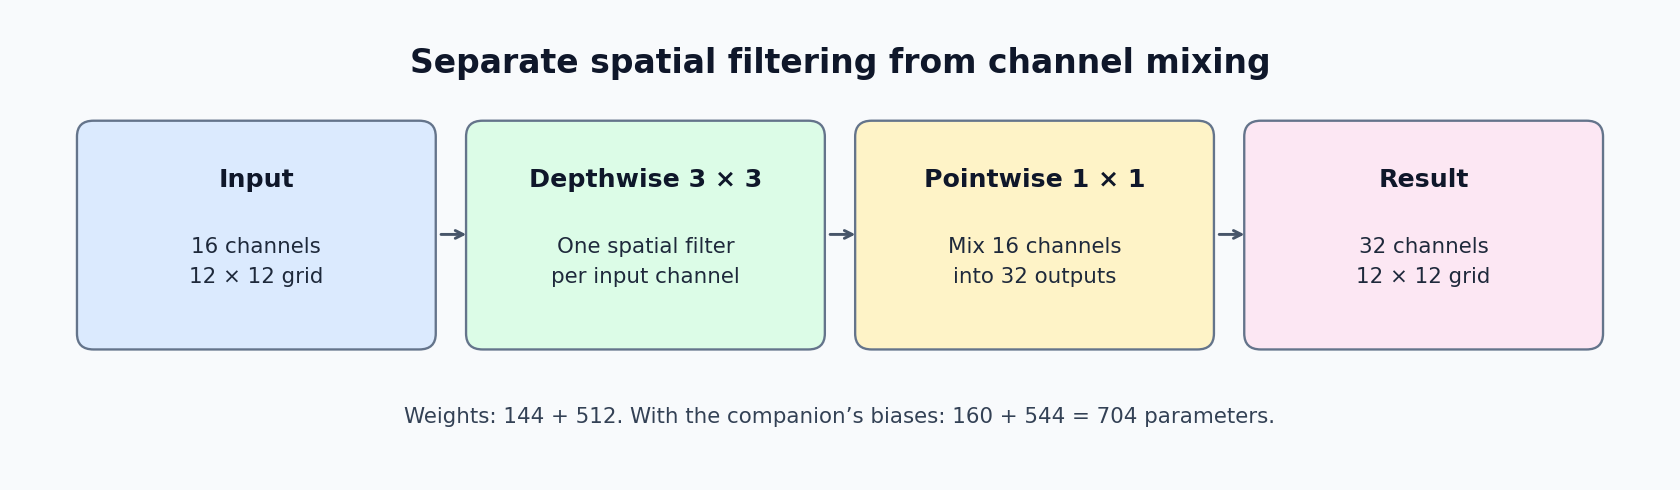

A standard convolution learns a spatial kernel for every input/output channel pair. A depthwise convolution with multiplier one instead applies one spatial filter to each input channel separately. A following pointwise convolution mixes those channels at each position.

For the companion's 16-input, 32-output, three-by-three comparison:

| Layer | Weights | Biases | Parameters |
| --- | --- | --- | --- |
| Standard $16\to32$, $3\times3$ | 4608 | 32 | 4640 |
| Depthwise: 16 filters, $3\times3$ | 144 | 16 | 160 |
| Pointwise $16\to32$, $1\times1$ | 512 | 32 | 544 |
| Separable total | 656 | 48 | 704 |

The companion implements depthwise connectivity with 16 groups for 16 input/output channels. The pointwise layer then supplies cross-channel mixing that depthwise filtering alone lacks. This structural idea is central to the [MobileNet paper](https://arxiv.org/abs/1704.04861).

A one-by-one convolution is not “no processing”: its channel mixture is learned at every spatial position.


## Derive the savings under explicit assumptions

Ignoring biases, standard weights are $K^2C_{in}C_{out}$ and depthwise-plus-pointwise weights are $K^2C_{in}+C_{in}C_{out}$ for a square kernel and multiplier one.

Their ratio is:

$$\frac{K^2C_{in}+C_{in}C_{out}}{K^2C_{in}C_{out}}=\frac1{C_{out}}+\frac1{K^2}.$$

For $K=3$ and $C_{out}=32$, this ratio is about 0.142361. Bias-enabled parameter counts from the companion give $704/4640\approx0.151724$, or about 84.83% fewer parameters.

At output grid $12\times12$ for one example, the standard operation uses $144(4608)=663552$ weight multiply-accumulates. The separated operation uses $144(656)=94464$, excluding bias additions, activations, and memory operations.

This factorization restricts which spatial/channel transformations one such block can represent. Fewer arithmetic operations do not establish equal accuracy. Actual speed also depends on kernel implementations, device, batch size, memory movement, and surrounding layers.

The companion calculates parameter counts, not latency or accuracy, so it should not be described as measuring either benefit.


## Compare complete designs under the task's constraints

| Constraint or observation | Candidate idea to investigate | Evidence needed |
| --- | --- | --- |
| Basic local recognition | Compact regular stack | Baseline and held-out quality |
| Deeper stack hard to optimize | Residual updates | Training behavior and validation |
| Several spatial scales matter | Parallel branches | Controlled task comparison |
| Earlier maps remain useful | Concatenated feature reuse | Quality and activation memory |
| Compute or parameter budget is tight | Bottleneck or depthwise factorization | Accuracy and measured resource use |

Keep the input resolution, training data, augmentation policy, and evaluation split comparable when investigating one structural change. If both architecture and training recipe change, a score difference cannot be attributed to the architecture alone.

Measure latency on the intended hardware and inference configuration. Parameter counts describe stored coefficients; activation memory depends on shape, batch size, and saved intermediates; arithmetic counts describe a selected set of operations. None is a complete substitute for the others.

A familiar family name does not specify a particular pretrained checkpoint, tokenizer-free image preprocessing, or output label mapping. Those contracts must be recorded separately if the design is used in a larger system.


## Interpret the companion and diagnose design mistakes

The companion checks a residual output's shape and compares standard and separated parameter counts. It creates depthwise and pointwise modules but does not benchmark or train them. Its selected shapes and counts establish structural mechanics only.

| Mistake | Consequence | Check |
| --- | --- | --- |
| Add tensors with different channel counts | Incompatible residual path | Matching projection |
| Concatenate branches with different grids | Incompatible spatial join | Padding, stride, and resize policy |
| Call grouped filtering full channel mixing | Incorrect connectivity interpretation | Group count and following pointwise layer |
| Compare weight-only count with bias-enabled count | Inconsistent savings | State counted terms |
| Infer speed directly from parameter count | Unsupported performance claim | Measure latency and memory |
| Equate receptive field with identical function | Incorrect equivalence | Channels and intervening nonlinearities |

When modifying a block, trace input/output shapes, channel connectivity, parameter counts, and task behavior. A correct local shape is necessary for composition, while held-out task evaluation determines whether the structural change is useful.


## Practice the structures and retain the tradeoffs

1. If $x=[1,2]$ and $F(x)=[-0.2,0.3]$, what is the residual sum?
2. What channel width results from concatenating 16 and eight channels at the same spatial shape?
3. How many weights are in a bias-free depthwise-plus-pointwise $8\to16$ block with a three-by-three depthwise kernel and multiplier one?
4. Does a lower parameter count establish lower latency?
5. What does the companion actually verify?

**Answers.** The residual sum is $[0.8,2.3]$. Concatenation gives 24 channels. The weight count is $8(9)+8(16)=200$. Lower parameter count alone does not establish latency. The companion verifies residual shape and the stated standard-versus-separated parameter counts.

**Remember:** small-filter stacks, parallel paths, residual addition, concatenated reuse, and separated spatial/channel processing are different tools. Choose an experiment that addresses a concrete constraint, calculate its interface and cost, and evaluate the resulting model rather than its name.

Continue with [Beyond Image Classification](36_Beyond_Image_Classification_Notes.ipynb), where task outputs may need positions and spatial structure that a classification head discards.
